In [1]:
## Development of experimental tools

Here, Sergei is developing some experemental tools and is doing some testing.
All these tests are dome using commitor obtained previously.

We download committor **r_traj.npy**, obtained by optimization earlier (with histories) in the one of **sCr-history-cycle-Copy?.ipynb** notebooks. There  optimization was run using all biomarkers (all 37 and probably including sex and age)

- Committor obtained from scenario 1, that means that we discard parts of the trajectories (after AKI3 happend)
- boundary conditions: either 0 or 1 at the last point of the trajectoprie depending on AKI3 results.
- Trajectories by admissions ID
#### DataFrame

First, we read data
**df = pd.read_csv('data_with_AKI3.csv')**

Second,  we discard parts of the trajectories (after AKI3 happend). We discard it using the function  **cut_after_AKI3** from **prepare_df2** notebook. (For all the manupalitons as creating Boudary conditions or  dublication the end of the trajectories, we use functions from the **prepare_df2** notebook). 


**Summary of Key Points**
- Original DataFrame from **data_with_AKI3.csv:** Contains 2902942 rows.
- the number of unique patients (trajectories): 756017
- **df_trimmed** DataFrame: with discarded part of the trajectories after  AKI3 happends (1 → AKI stage 3 (B)) contains 2705819  rows.
- the number of unique patients who had AKI3: 14733
- the log transformation applyed to all the data from 4th column
-  **df_copy**: we use 39 biomarkers for training model 

Next, we gonna use **df_copy** DataFrame for analysis.

#### CommittorNE

Next, we import **optimalrcs** library. 

**r_traj.npy** is a committor. It means that  for any point of the trajectory (patient's particular date with blood test) it predicts probability to have AKI3 during their current admission to the hospital


####  Read and preprocessing the data.

We start with the correct/standard notebook for reading the preprocessing the data. 

In [2]:
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="The raw code for this Python notebook is by default hidden for easier reading. Click here to toggle on/off the raw code."></form>''')

First, we define some global variables that define how we read and preprocess the data

In [3]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH']='true'

In [4]:
# Import needed libraries
import pandas as pd
from IPython.display import display
import numpy as np

In [5]:
#load preprocessed df
df = pd.read_csv('../data_with_AKI3.csv')

In [6]:
df[['ID', 'Date_Test']].duplicated().sum()

0

Count the number of unique patients trajectories. 


In [7]:
print(df.shape)
unique_patients = df['ID'].nunique()
print("Number of unique patients (trajectories):", unique_patients)

(2902942, 43)
Number of unique patients (trajectories): 756017


In [8]:
def cut_after_AKI3(df, status_col='AKI3', admission_col='ID'):
    # Identify the first index where AKI3 is True for each admission_id
    first_true_indices = (
        df[df[status_col]]
        .groupby(admission_col, sort=False)
        .apply(lambda group: group.index.min(), include_groups=False)
    )

    # Map each row to the first True index for its admission_id
    first_true_map = df[admission_col].map(first_true_indices)

    # Create a mask:
    # - Keep rows where AKI3 is never True (first_true_map is NaN)
    # - Or where the row index is less than or equal to the first True index
    mask = first_true_map.isna() | (df.index <= first_true_map)

    # Filter the DataFrame
    trimmed_df = df[mask].copy()

    return trimmed_df

df_trimmed=cut_after_AKI3(df)
#df_trimmed.head()

In [9]:
df_trimmed.tail()

,ID,patpseudoid,Date_Test,AKI3,ALT,APTT,APTT Ratio,APTTSP,Albumin,Alkaline Phosphatase,...,Platelets,Potassium,RBC Distrn Width,Red Cell Count,Sodium,TSH,Urea,White cell count,sex,age
2902937,1737629,469388,2020-12-09 20:20:00,False,19.000000,24.40000,0.800000,42.60438,24.000000,1066.00000,...,88.0,3.8,15.3,3.68,134.0,3.120071,29.0,15.95,2.0,82.0
2902938,1737629,469388,2020-12-12 10:02:00,False,18.000000,24.40000,0.800000,42.60438,20.000000,690.00000,...,121.0,4.2,15.1,3.31,136.0,3.120071,18.9,6.47,2.0,82.0
2902939,1737629,469388,2020-12-14 09:50:00,False,31.000000,24.40000,0.800000,42.60438,20.000000,665.00000,...,171.0,4.7,15.0,3.44,136.0,3.120071,9.3,7.66,2.0,82.0
2902940,1737631,469389,2013-05-21 12:37:00,False,19.000000,32.80112,1.093246,42.60438,42.000000,139.00000,...,288.0,4.6,15.7,4.64,134.0,3.120071,7.0,19.45,0.5,87.0
2902941,1737631,469389,2013-05-22 01:20:00,False,57.223286,32.80112,1.093246,42.60438,31.090393,224.30688,...,278.0,4.2,15.9,4.65,133.0,3.120071,9.8,21.46,0.5,87.0


In [10]:
print("Original shape:", df.shape)
print("Trimmed shape:", df_trimmed.shape)
print(df[df['AKI3'] == 1]['ID'].nunique())  ##number of unique patients who had AKI3
print(df_trimmed[df_trimmed['AKI3'] == 1]['ID'].nunique())


Original shape: (2902942, 43)
Trimmed shape: (2705819, 43)
14733
14733


In [11]:
# Reset the Index
df_trimmed = df_trimmed.reset_index(drop=True)
print(df_trimmed.shape)
df_trimmed.tail()

(2705819, 43)


,ID,patpseudoid,Date_Test,AKI3,ALT,APTT,APTT Ratio,APTTSP,Albumin,Alkaline Phosphatase,...,Platelets,Potassium,RBC Distrn Width,Red Cell Count,Sodium,TSH,Urea,White cell count,sex,age
2705814,1737629,469388,2020-12-09 20:20:00,False,19.000000,24.40000,0.800000,42.60438,24.000000,1066.00000,...,88.0,3.8,15.3,3.68,134.0,3.120071,29.0,15.95,2.0,82.0
2705815,1737629,469388,2020-12-12 10:02:00,False,18.000000,24.40000,0.800000,42.60438,20.000000,690.00000,...,121.0,4.2,15.1,3.31,136.0,3.120071,18.9,6.47,2.0,82.0
2705816,1737629,469388,2020-12-14 09:50:00,False,31.000000,24.40000,0.800000,42.60438,20.000000,665.00000,...,171.0,4.7,15.0,3.44,136.0,3.120071,9.3,7.66,2.0,82.0
2705817,1737631,469389,2013-05-21 12:37:00,False,19.000000,32.80112,1.093246,42.60438,42.000000,139.00000,...,288.0,4.6,15.7,4.64,134.0,3.120071,7.0,19.45,0.5,87.0
2705818,1737631,469389,2013-05-22 01:20:00,False,57.223286,32.80112,1.093246,42.60438,31.090393,224.30688,...,278.0,4.2,15.9,4.65,133.0,3.120071,9.8,21.46,0.5,87.0


Our dataframe **df_trimmed** now has a shape (2705819, 43). We also reseted index.
First, we make a copy of **df_trimmed**.

In [12]:

df_copy = df_trimmed.copy()


Create  **b_traj**, the array with boundaries, needed for the optimization later, with the same shape as **i_traj** filled with values 2, and with values 0 or 1 at the last point of each trajectory. 

In [13]:
def create_b_traj(df):

    temp=df[['ID','AKI3']].copy()
    
    last_indices = temp.groupby('ID').tail(1).index

    temp['label']=temp['AKI3'].astype(int)

    # Store original values at the last index of each group
    original_last_values = temp.loc[last_indices, 'label']

    # Replace all values in 'label' with 2
    temp['label'] = 2

    # Restore the original values at the last index of each group
    temp.loc[last_indices, 'label'] = original_last_values

    b_traj=temp['label'].to_numpy()

    del temp

    return b_traj

b_traj=create_b_traj(df_copy)

b_traj.shape, np.unique(b_traj), b_traj

((2705819,), array([0, 1, 2]), array([2, 2, 0, ..., 0, 2, 0]))

In [14]:
i_traj=df_copy['ID'].to_numpy()
traj_ends=np.where(np.roll(i_traj,-1)!=i_traj)[0]
print(len(i_traj))
print(i_traj[:10])  
print(traj_ends[:10]) 

2705819
[2 2 2 7 7 7 8 8 8 8]
[ 2  5 12 16 23 32 37 41 44 45]


Next, we will apply 

1. Natural logarithm to the values of the data  (all the data in the data frame **df_copy**). This is often done to normalize data or reduce skewness. For this purpose we normalize data in every column starting from column 4 in **df_copy** data frame. 

2. Convert time strings to times


In [15]:
# pre compute logs
for var in df_copy.columns[4:]:df_copy[var]=np.log(df_copy[var])

In [16]:
# the number of unique patients with AKI3_boundary  = 1
num_unique_patients = df_copy[df_copy['AKI3'] == True]['ID'].nunique()
print("Number of unique patients with AKI3 = 1:", num_unique_patients)

# the number of unique patients
all_unique_patients = df_copy['ID'].nunique()
print("Number of all unique patients:", all_unique_patients)

first_patient_index = df_copy[df_copy['AKI3'] == True].index[0]
print("Index of the first patient with AKI3 = 1:", first_patient_index)


Number of unique patients with AKI3 = 1: 14733
Number of all unique patients: 756017
Index of the first patient with AKI3 = 1: 299


In [17]:
import datetime
# time is measured in days


# Convert the 'Date_Test' column to datetime format
df_copy['Date_Test'] = pd.to_datetime(df_copy['Date_Test'])

# Reference start time
start_time = datetime.datetime(2011, 1, 1, 1, 1, 1)
lt=[(t-start_time).total_seconds()/60/60/24 for t in df_copy['Date_Test']]
ttraj=np.asarray(lt)
print(len(ttraj))
#print(ttraj[290:300])

2705819


In [18]:
del df_trimmed
del df

In [19]:
df_copy.shape

(2705819, 43)

Next, we gonna use **df_copy** DataFrame for analysis.




#### **CommittorNE**

Next, we import optimalrcs library and download committor **r_traj.npy**. 


In [20]:

import sys
#sys.path.append('/home/staff7/fbsskr/Notebooks/optimalrcs-cupy/')
#import optimalrcs,metrics,plots
#import matplotlib.pyplot as plt

sys.path.append('/home/fbsskr/Notebooks/optimalrcs/')
from optimalrcs import optimalrcs,metrics,plots
import matplotlib.pyplot as plt
from optimalrcs import experimental

2026-02-18 11:57:34.054917: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-18 11:57:34.063802: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-18 11:57:34.066487: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-18 11:57:34.072946: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [21]:
import gc
data={}

[0, 1, 2, 3, 4, 5, 6, 7, 8]
7


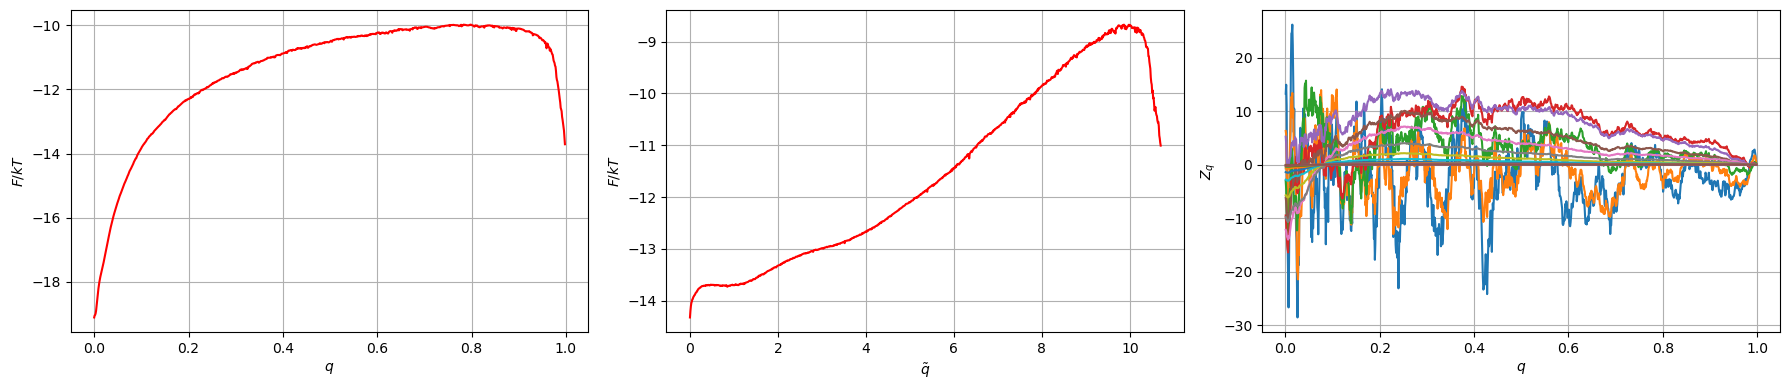

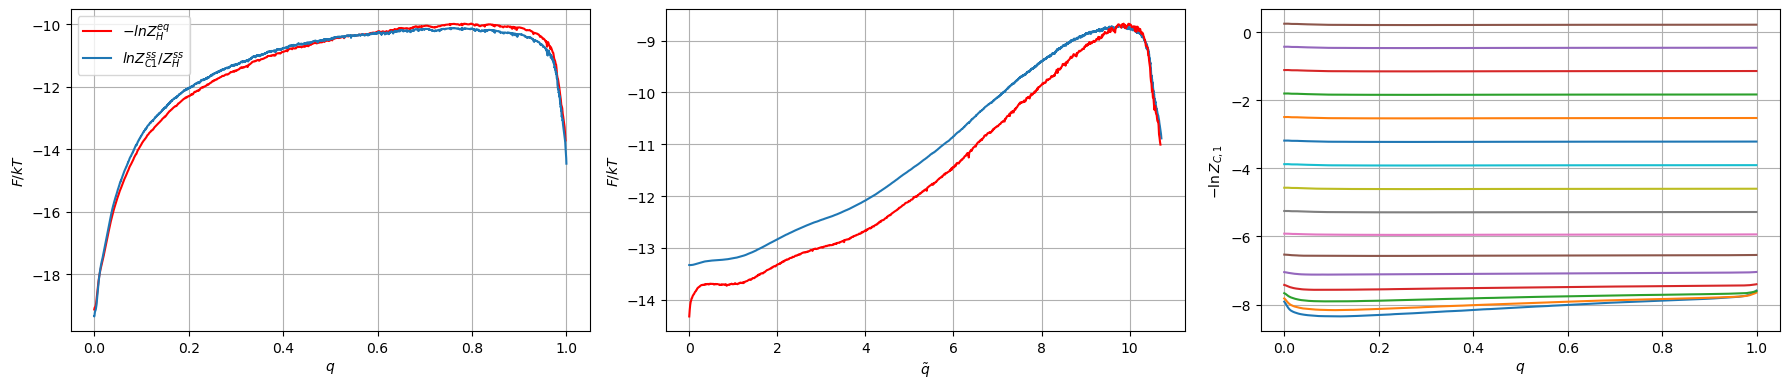

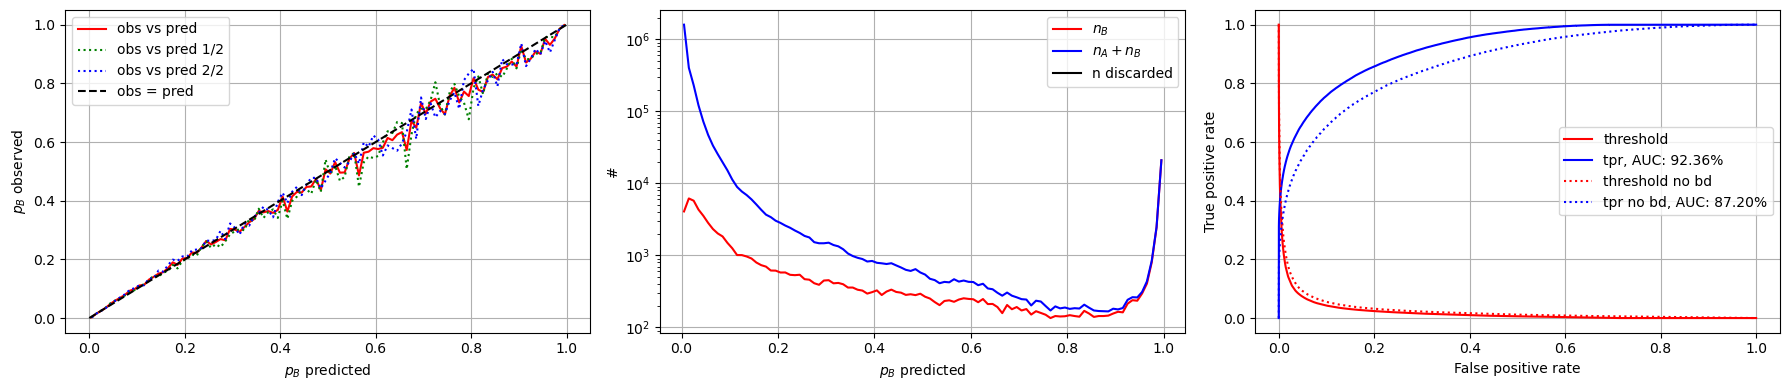

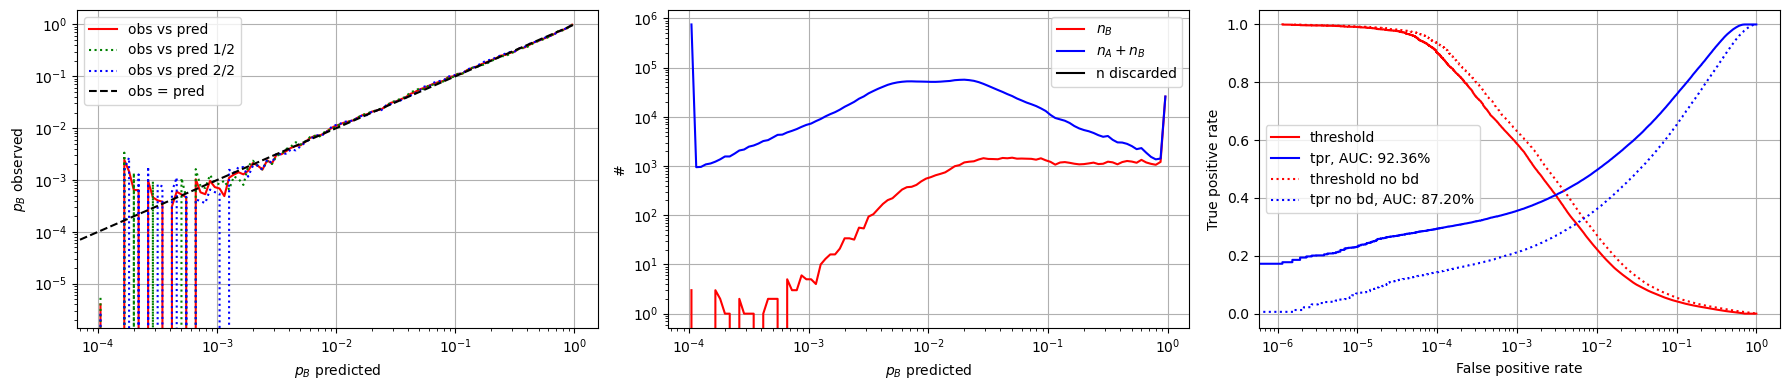

In [41]:
pcs=2/3
import tensorflow as tf
def comp_y():
    var=np.random.choice(df_copy.columns[4:])
    y=df_copy[var].to_numpy()
    if np.random.random()>pcs: return y
    k=np.random.randint(kmax)+1
    if np.random.random()>0.5:
        return tf.math.cos(k*y)
    else:
        return tf.math.sin(k*y)

kmax=2*np.pi*10


optimalrcs.envelope_scale=0.01
nn=8
history_delta_t = list(range(nn+1))
print (history_delta_t)
gamma=1
yr_type=['y(t-d),r(t-d)', 'lndt,r(t-d)', 'lndt,y(t-d)', 'lndt,r(t)', 'lndt,y(t)']
name='%i %g' %(nn,gamma)


for j in (7,):
    print(j)
    q = optimalrcs.CommittorNE(boundary0=b_traj==0, boundary1=b_traj==1, i_traj=i_traj, t_traj=ttraj)
    np.random.seed(0)
    q.set_fixed_traj_length_trap(1000000, trap_boundary = b_traj<2)
    np.random.seed(j)
    q.r_traj=np.load('r_traj.npy')
    q.plots_feps()
    q.w_traj=np.ones_like(ttraj)
    experimental.plots_feps_eq_q(q)
    q.plots_obs_pred()
    q.plots_obs_pred(log_scale=True,log_scale_pmin=1e-4)

Import **experimental** library to make some new  ptots

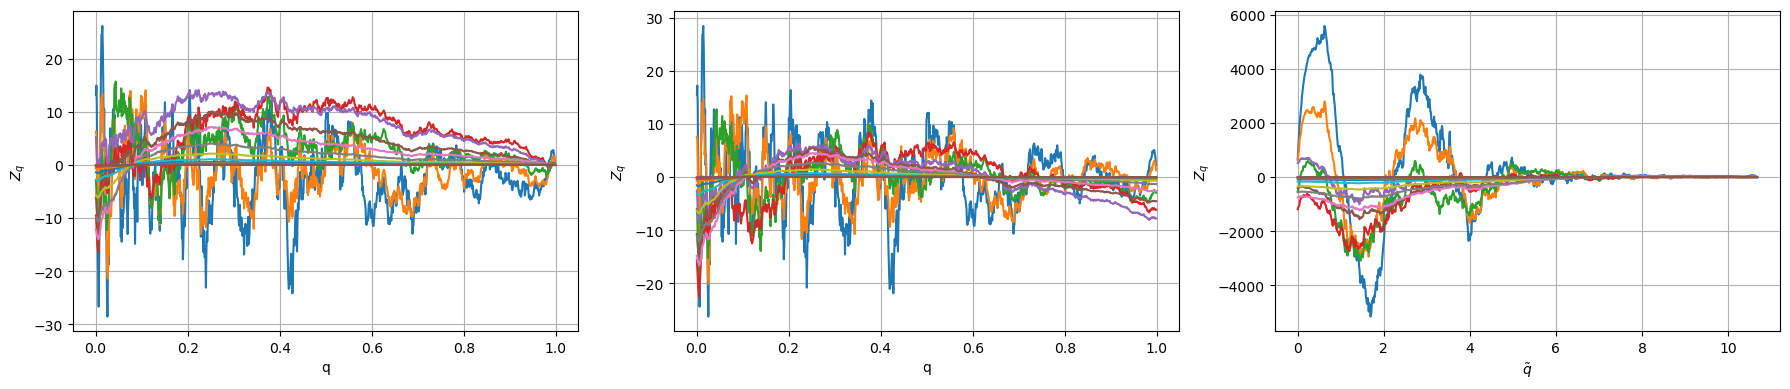

In [23]:
import importlib
importlib.reload(experimental)

experimental.plots_zq(q)

Next we plot committor histogram, predicited on the first day (figure 1),  and committor, 
predicted on the 2 days before the last one.

/home/fbsskr/Notebooks/optimalrcs/optimalrcs/experimental.py:487: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


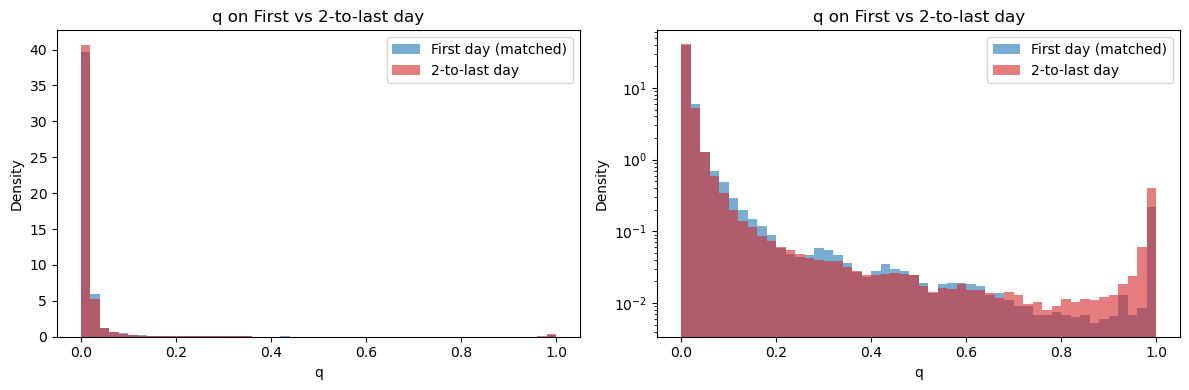

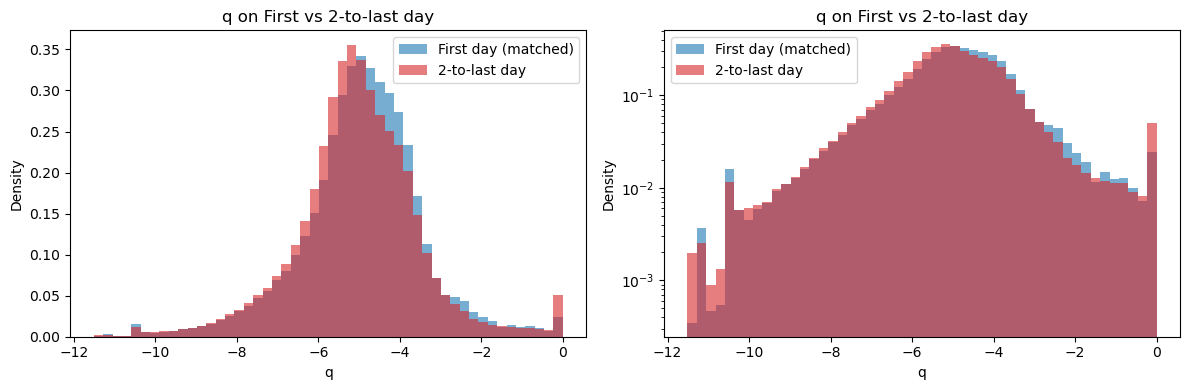

In [24]:
experimental.plot_q_first_vs_k_last_matched(q.r_traj, df_copy['ID'].to_numpy(), k=1)
experimental.plot_q_first_vs_k_last_matched(np.log(q.r_traj+1e-5), df_copy['ID'].to_numpy(), k=1)

/home/fbsskr/Notebooks/optimalrcs/optimalrcs/experimental.py:573: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


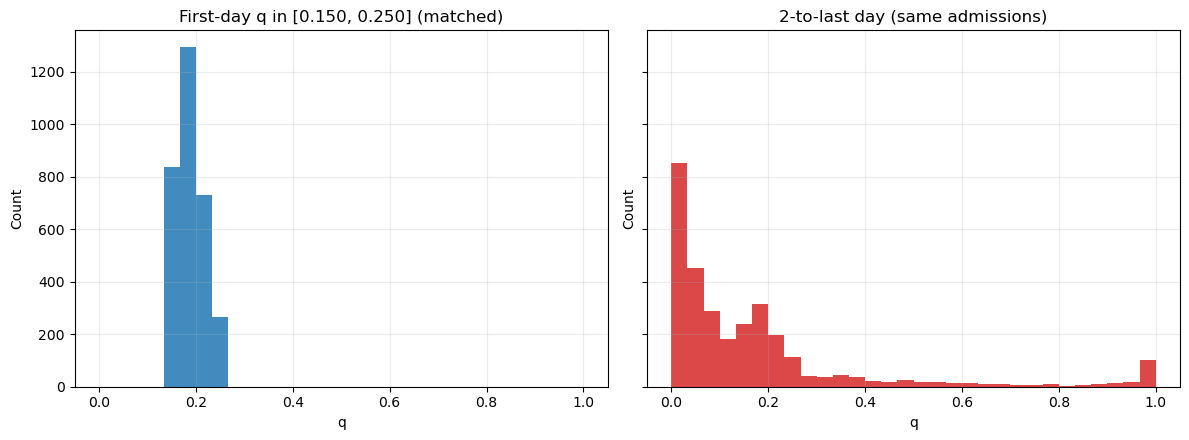

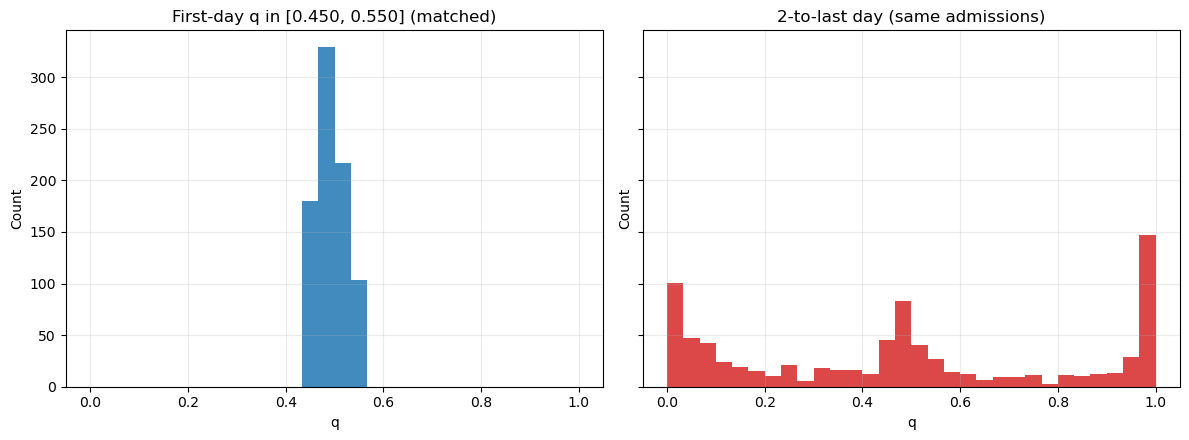

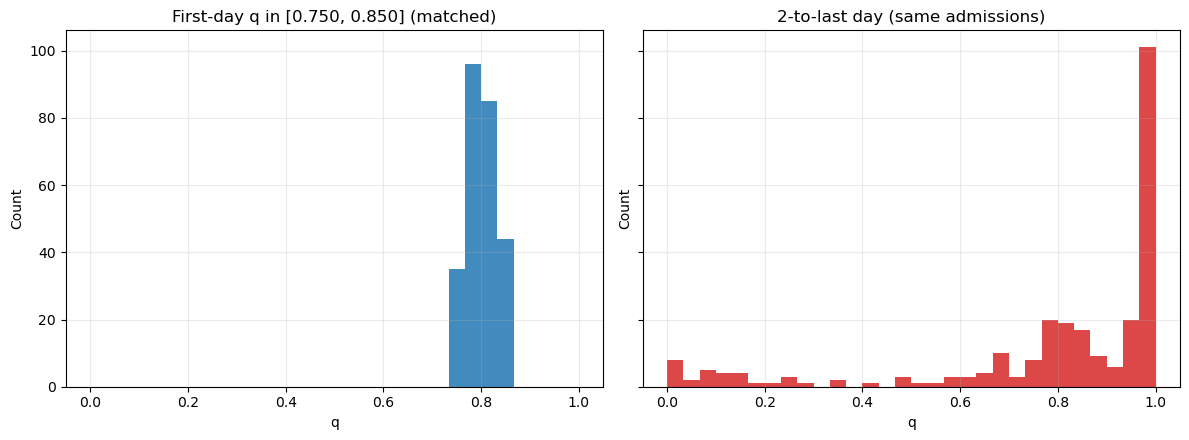

In [25]:
_ = experimental.plot_k_last_given_first_bin_shared_x(q.r_traj, df_copy['ID'].to_numpy(), k=1, first_range=(0.15, 0.25), bins=30, density=False)

_ = experimental.plot_k_last_given_first_bin_shared_x(q.r_traj, df_copy['ID'].to_numpy(), k=1, first_range=(0.45, 0.55), bins=30, density=False)

_ = experimental.plot_k_last_given_first_bin_shared_x(q.r_traj, df_copy['ID'].to_numpy(), k=1, first_range=(0.75, 0.85), bins=30, density=False)


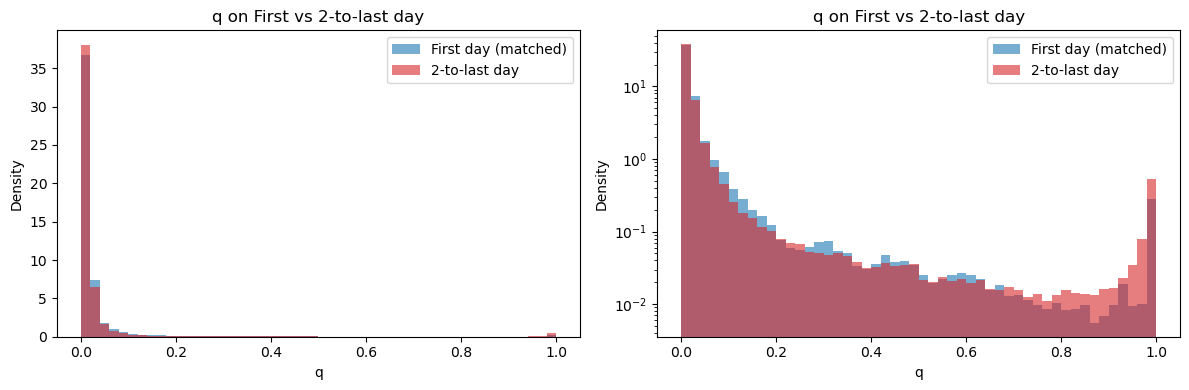

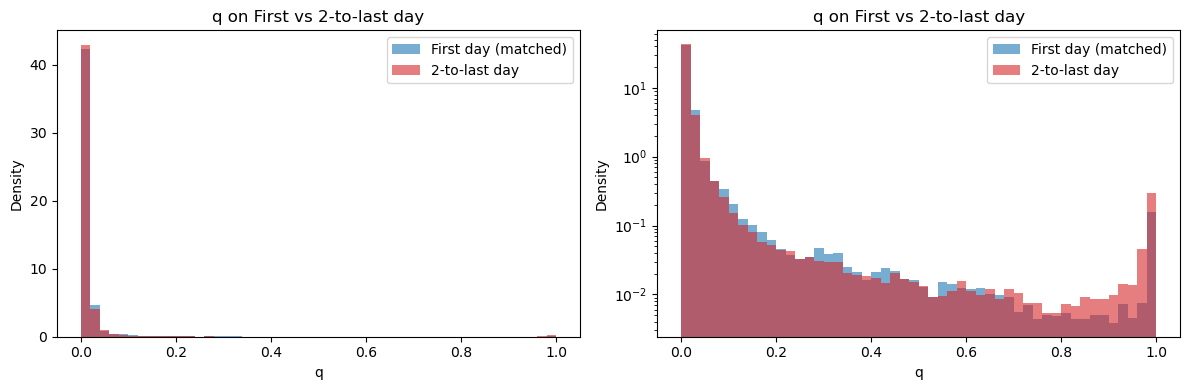

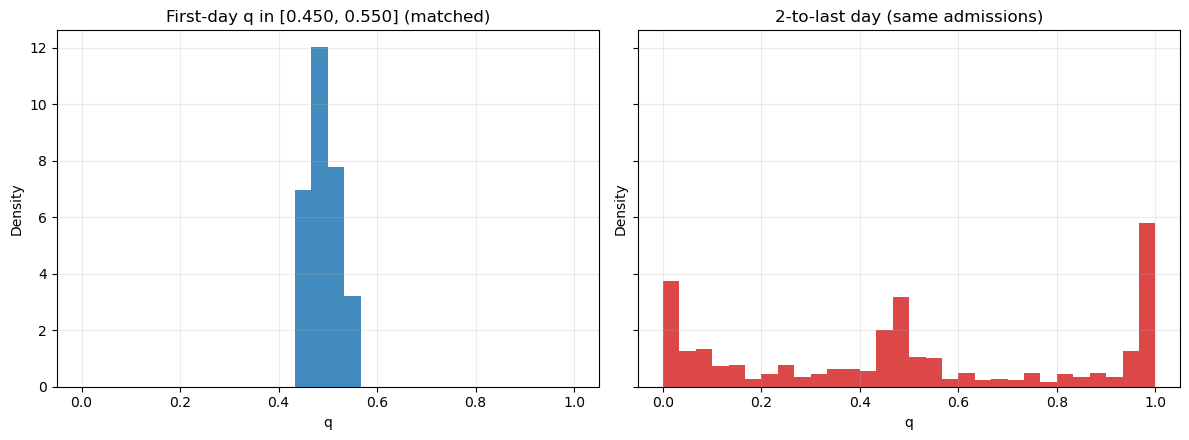

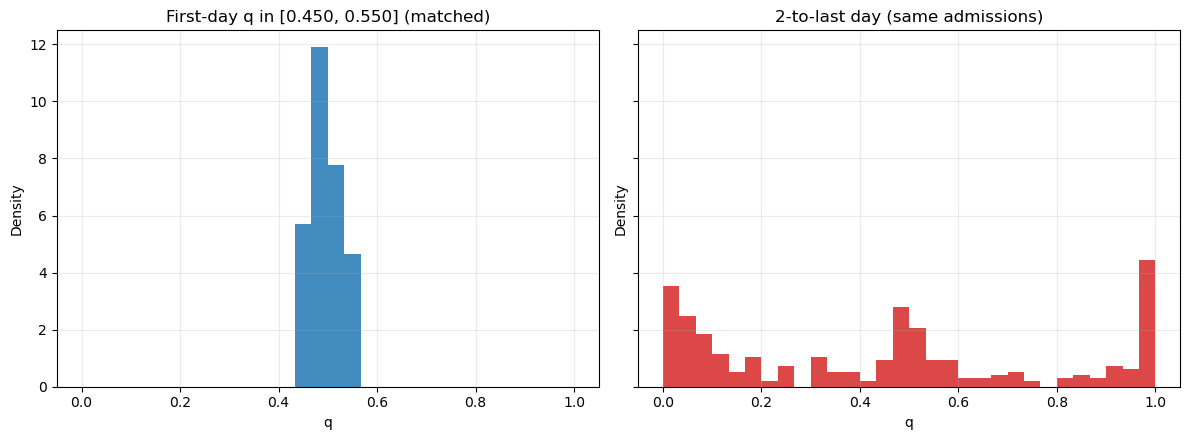

In [26]:
# dependence on sex

male=df_copy['sex']>0
female=df_copy['sex']<0

# on age
#male=df_copy['age']>np.log(90)
#female=df_copy['age']<np.log(90)

experimental.plot_q_first_vs_k_last_matched(q.r_traj[male], df_copy['ID'].to_numpy()[male], k=1)
experimental.plot_q_first_vs_k_last_matched(q.r_traj[female], df_copy['ID'].to_numpy()[female], k=1)
_ = experimental.plot_k_last_given_first_bin_shared_x(q.r_traj[male], df_copy['ID'].to_numpy()[male], k=1, first_range=(0.45, 0.55), bins=30, density=True)
_ = experimental.plot_k_last_given_first_bin_shared_x(q.r_traj[female], df_copy['ID'].to_numpy()[female], k=1, first_range=(0.45, 0.55), bins=30, density=True)


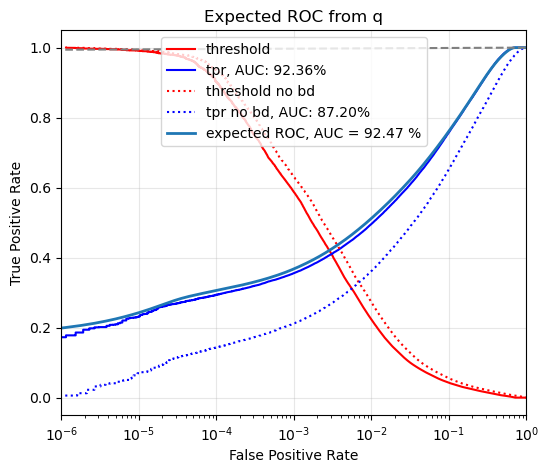

In [27]:
plt.figure(figsize=(6, 5))
plots.plot_roc_curve(plt.gca(), q.r_traj, q.future_boundary, log_scale=True)
plt.xlim(1e-6,1)

_=experimental.expected_roc(q.r_traj,plt=plt)

/localhome/data/fbsskr-conda/envs/tf_gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


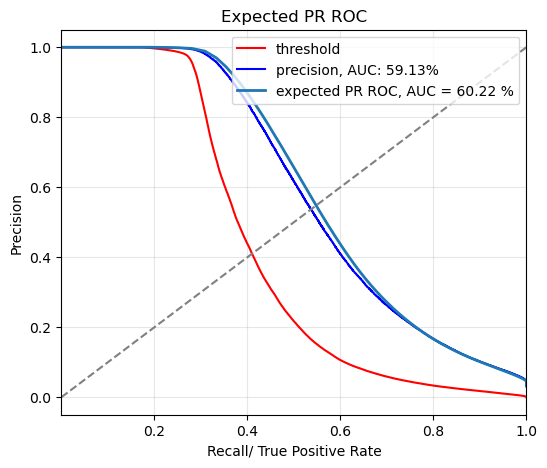

0.6021605851292131


In [28]:
plt.figure(figsize=(6, 5))
plots.plot_pr_curve(plt.gca(), q.r_traj, q.future_boundary)
plt.xlim(1e-6,1)

_=experimental.expected_roc_pr(q.r_traj,plt=plt)
print(experimental.expected_auc_pr(q))

In [29]:
import numpy as np
import pandas as pd

def expected_metrics(
    q,
    thresholds=None,
    sample_weight=None,
    clip_probs=True,
):
    """
    Compute expected classification metrics from committor/probabilities q at multiple thresholds.

    This uses only q (no labels). At threshold t, predicted positive is (q >= t).
    Expected counts:
        TP = sum_{q>=t} q
        FP = sum_{q>=t} (1-q)
        TN = sum_{q< t} (1-q)
        FN = sum_{q< t} q
    Totals: P = sum q, N = sum (1-q)

    Parameters
    ----------
    q : array-like of shape (n,)
        Committor/probabilities in [0, 1].
    thresholds : array-like, optional
        Thresholds at which metrics are computed. Default: np.arange(0.1, 1.0, 0.1).
    sample_weight : array-like of shape (n,), optional
        Non-negative weights (e.g., to account for irregular sampling).
    clip_probs : bool, default True
        Clip q into [0, 1] to avoid minor numerical violations.

    Returns
    -------
    pd.DataFrame
        One row per threshold with expected confusion counts and derived metrics:
        ['threshold','TP','FP','TN','FN','P','N','prevalence','accuracy',
         'precision','recall','sensitivity','specificity','fpr','fnr','npv',
         'fdr','for','f1','f2','mcc','balanced_accuracy','youden_j',
         'lr_plus','lr_minus','jaccard','pred_pos','pred_neg'].
    """
    q = np.asarray(q, dtype=float)
    if q.size == 0:
        raise ValueError("Empty q")

    if clip_probs:
        q = np.clip(q, 0.0, 1.0)

    if thresholds is None:
        thresholds = np.arange(0.1, 1.0, 0.1)
    thresholds = np.asarray(thresholds, dtype=float)

    # Weights
    if sample_weight is None:
        w = np.ones_like(q, dtype=float)
    else:
        w = np.asarray(sample_weight, dtype=float)
        if w.shape != q.shape:
            raise ValueError("sample_weight must have the same shape as q")
        if np.any(w < 0):
            raise ValueError("sample_weight must be non-negative")

    # Sort q ascending for prefix sums
    order = np.argsort(q, kind="mergesort")
    q_sorted = q[order]
    w_sorted = w[order]

    qw = q_sorted * w_sorted
    invqw = (1.0 - q_sorted) * w_sorted

    # Prefix sums with 0 padding to make slicing easy
    cum_qw    = np.r_[0.0, np.cumsum(qw)]
    cum_invqw = np.r_[0.0, np.cumsum(invqw)]
    cum_w     = np.r_[0.0, np.cumsum(w_sorted)]

    total_q   = float(cum_qw[-1])      # P
    total_inv = float(cum_invqw[-1])   # N
    total_w   = float(cum_w[-1])       # P+N (== sum weights)

    def _safe_div(a, b):
        return np.nan if b == 0.0 else (a / b)

    rows = []
    for t in thresholds:
        # idx = number of elements with q < t
        idx = int(np.searchsorted(q_sorted, t, side="left"))

        # Expected counts based on prefix sums
        TP = total_q   - cum_qw[idx]
        FP = total_inv - cum_invqw[idx]
        TN = cum_invqw[idx]
        FN = cum_qw[idx]

        P, N = total_q, total_inv
        pred_pos = TP + FP
        pred_neg = TN + FN

        # Rates
        TPR = _safe_div(TP, P)                     # recall/sensitivity
        FNR = _safe_div(FN, P)
        FPR = _safe_div(FP, N)
        TNR = _safe_div(TN, N)                     # specificity

        # Predictive values
        precision = _safe_div(TP, pred_pos)        # PPV
        npv       = _safe_div(TN, pred_neg)        # NPV
        fdr       = _safe_div(FP, pred_pos)        # 1 - precision
        _for      = _safe_div(FN, pred_neg)        # false omission rate

        # Scores
        accuracy  = _safe_div(TP + TN, total_w)
        f1        = _safe_div(2 * TP, 2 * TP + FP + FN)

        # F2 (beta=2; recall-weighted)
        beta = 2.0
        if precision is np.nan or TPR is np.nan:
            f2 = np.nan
        else:
            denom = (beta**2) * precision + TPR
            f2 = np.nan if denom == 0 else ((1 + beta**2) * precision * TPR / denom)

        # Matthews Correlation Coefficient
        denom_mcc = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
        mcc = _safe_div((TP * TN - FP * FN), denom_mcc)

        balanced_accuracy = np.nan if (np.isnan(TPR) or np.isnan(TNR)) else (TPR + TNR) / 2.0
        youden_j = np.nan if (np.isnan(TPR) or np.isnan(TNR)) else (TPR + TNR - 1.0)

        # Likelihood ratios
        lr_plus  = _safe_div(TPR, FPR) if not np.isnan(TPR) and not np.isnan(FPR) else np.nan
        lr_minus = _safe_div(FNR, TNR) if not np.isnan(FNR) and not np.isnan(TNR) else np.nan

        # Jaccard / Threat score
        jaccard = _safe_div(TP, TP + FP + FN)

        rows.append({
            "threshold": t,
            "TP": TP, "FP": FP, "TN": TN, "FN": FN,
            "P": P, "N": N,
            "prevalence": _safe_div(P, P + N),
            "pred_pos": pred_pos, "pred_neg": pred_neg,
            "accuracy": accuracy,
            "precision": precision,
            "recall": TPR,
            "sensitivity": TPR,
            "specificity": TNR,
            "fpr": FPR,
            "fnr": FNR,
            "npv": npv,
            "fdr": fdr,
            "for": _for,
            "f1": f1,
            "f2": f2,
            "mcc": mcc,
            "balanced_accuracy": balanced_accuracy,
            "youden_j": youden_j,
            "lr_plus": lr_plus,
            "lr_minus": lr_minus,
            "jaccard": jaccard,
        })

    df = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)
    return df

Emetrics=expected_metrics(q.r_traj)
Emetrics

,threshold,TP,FP,TN,FN,P,N,prevalence,pred_pos,pred_neg,...,fdr,for,f1,f2,mcc,balanced_accuracy,youden_j,lr_plus,lr_minus,jaccard
0,0.1,53849.802486,82603.197514,2.536616e+06,32749.511666,86599.314152,2.619220e+06,0.032005,136453.0,2569366.0,...,0.605360,0.012746,0.482845,0.557624,0.474793,0.795145,0.590290,19.717177,0.390488,0.318257
1,0.2,45513.345657,30572.654343,2.588647e+06,41085.968495,86599.314152,2.619220e+06,0.032005,76086.0,2629733.0,...,0.401817,0.015624,0.559526,0.538641,0.547148,0.756945,0.513890,45.025971,0.480041,0.388432
2,0.3,40586.469260,15266.530740,2.603953e+06,46012.844892,86599.314152,2.619220e+06,0.032005,55853.0,2649966.0,...,0.273334,0.017364,0.569825,0.504493,0.572970,0.731420,0.462841,80.407839,0.534445,0.398431
3,0.4,36811.627856,8067.372144,2.611152e+06,49787.686296,86599.314152,2.619220e+06,0.032005,44879.0,2660940.0,...,0.179758,0.018711,0.559965,0.470405,0.581589,0.711000,0.422000,138.009952,0.576696,0.388855
4,0.5,33691.641162,4209.358838,2.615010e+06,52907.672990,86599.314152,2.619220e+06,0.032005,37901.0,2667918.0,...,0.111062,0.019831,0.541230,0.438353,0.580285,0.693722,0.387445,242.082664,0.611931,0.371018
5,0.6,31216.809095,2173.190905,2.617046e+06,55382.505057,86599.314152,2.619220e+06,0.032005,33390.0,2672429.0,...,0.065085,0.020724,0.520326,0.410978,0.573397,0.679822,0.359644,434.458305,0.640057,0.351650
6,0.7,29070.239930,993.760070,2.618226e+06,57529.074222,86599.314152,2.619220e+06,0.032005,30064.0,2675755.0,...,0.033055,0.021500,0.498361,0.386099,0.563041,0.667654,0.335307,884.758101,0.664565,0.331878
7,0.8,27504.267960,463.732040,2.618756e+06,59095.046192,86599.314152,2.619220e+06,0.032005,27968.0,2677851.0,...,0.016581,0.022068,0.480142,0.367345,0.552412,0.658713,0.317427,1793.867910,0.682517,0.315912
8,0.9,25974.108736,191.891264,2.619028e+06,60625.205416,86599.314152,2.619220e+06,0.032005,26166.0,2679653.0,...,0.007334,0.022624,0.460675,0.348587,0.539331,0.649931,0.299861,4093.953679,0.700117,0.299271


In [30]:
Emetrics.columns

Index(['threshold', 'TP', 'FP', 'TN', 'FN', 'P', 'N', 'prevalence', 'pred_pos',
       'pred_neg', 'accuracy', 'precision', 'recall', 'sensitivity',
       'specificity', 'fpr', 'fnr', 'npv', 'fdr', 'for', 'f1', 'f2', 'mcc',
       'balanced_accuracy', 'youden_j', 'lr_plus', 'lr_minus', 'jaccard'],
      dtype='object')

In [31]:
Emetrics[['threshold','specificity','sensitivity', 'fpr']]

,threshold,specificity,sensitivity,fpr
0,0.1,0.968463,0.621827,0.031537
1,0.2,0.988328,0.525562,0.011672
2,0.3,0.994171,0.468670,0.005829
3,0.4,0.996920,0.425080,0.003080
4,0.5,0.998393,0.389052,0.001607
5,0.6,0.999170,0.360474,0.000830
6,0.7,0.999621,0.335687,0.000379
7,0.8,0.999823,0.317604,0.000177
8,0.9,0.999927,0.299934,0.000073


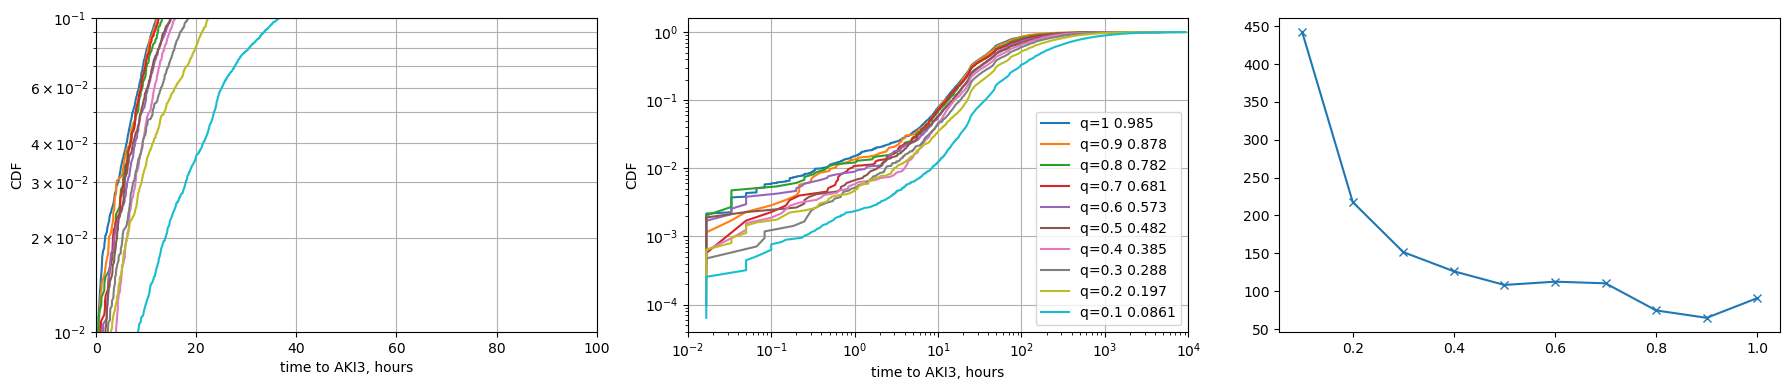

In [32]:
experimental.plots_tpt_q(q, time_scale=24)

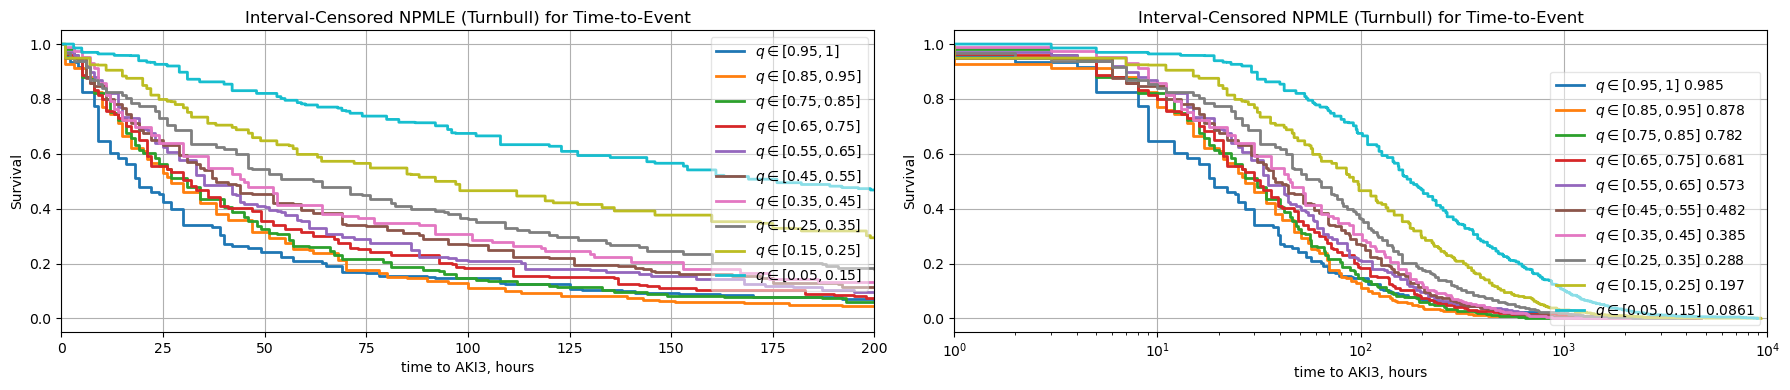

TypeError: plots_SA_q() got an unexpected keyword argument 'both'

In [34]:
### more accurate way to estimate time distribution to AKI3, takes into account interval censoring 

experimental.plots_SA_q(q, time_scale=24, n_max=1000)

### consider transitions to node A as censored events
experimental.plots_SA_q(q, time_scale=24, both=True, n_max=1000)

In [ ]:
# different ways to extract and plot patients trajectories

patient id 70


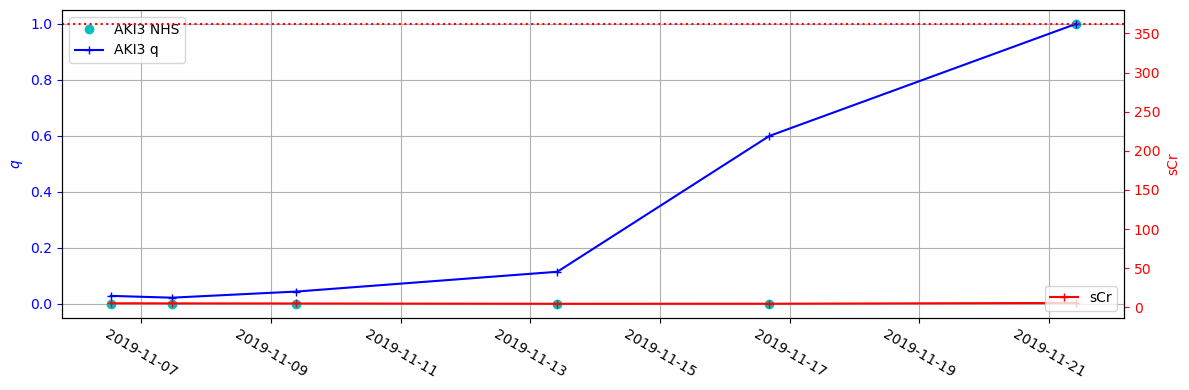

In [35]:
# first patient from all patients with AKI3, skip 5 frames form the begining. 'selecting patients based on patpseudoid' 

experimental.plots_patient_traj(1,df_copy,q,skip=4,id_col='patpseudoid')

patient id 3293


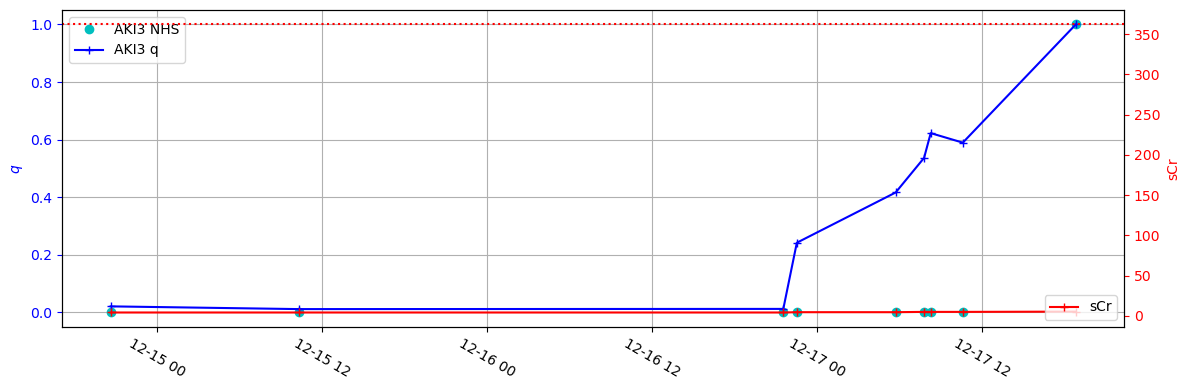

In [36]:
#second patienet from patients visiting 0.6-0.7 q range, skipping 15 first and 1 last point from trajectory

experimental.plots_patient_traj(2,df_copy,q,with_AKI3=False, qrange=(0.6,0.7), skip=0, skip_end=None, id_col='ID')

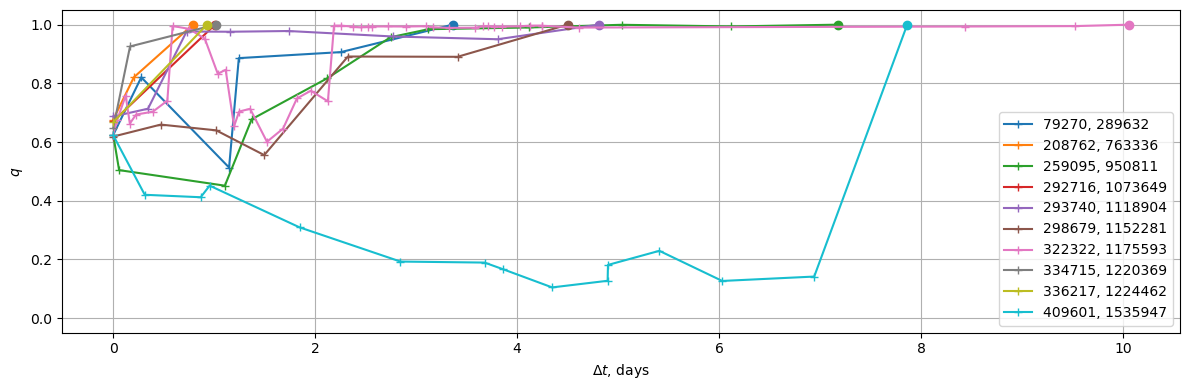

In [37]:
experimental.plots_patient_trajs(10,df_copy,q,with_AKI3=True, qrange=(0.6,0.7), id_col='ID', seed=3)

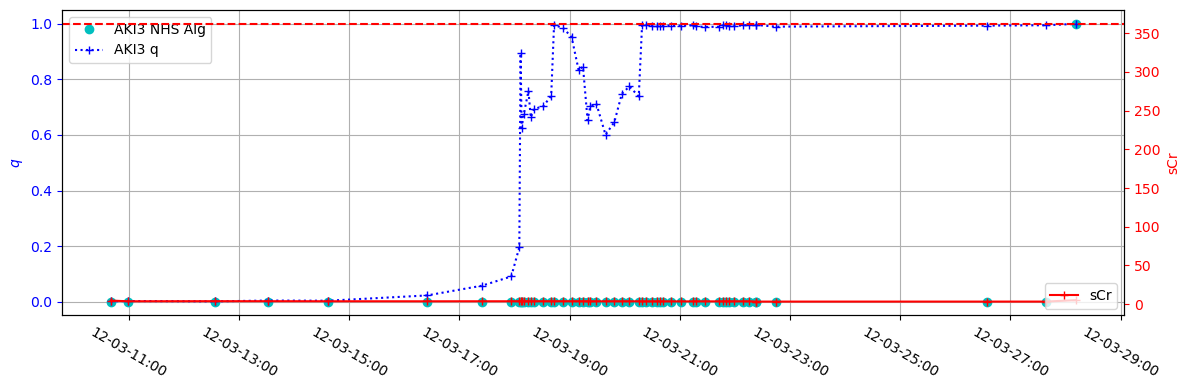

In [38]:
experimental.plots_patient_traj_id(1175593,df_copy,q, id_col='ID')

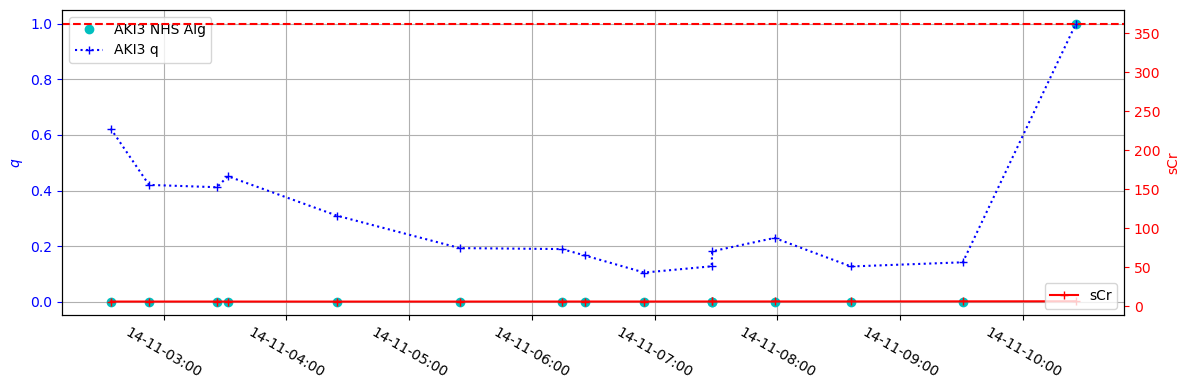

In [39]:
experimental.plots_patient_traj_id(1535947,df_copy,q, id_col='ID')

In [ ]:
importlib.reload(experimental)

In [ ]:
#stop

u, force, q2qn, qn2q=experimental.comp_force_q(q)

np.random.seed(0)
x_traj,b_traj,p_traj,t_traj=experimental.diff(force, q2qn(0), q2qn(1), diffusion_coeff=1, dt=1/24, n_steps=3000000, n_patients=1, isave=10, p_save=2) # time in days

#x_traj,b_traj,p_traj,t_traj=diff(force, q2qn(0), q2qn(1), diffusion_coeff=1, dt=1/24, n_steps=3000000, n_patients=10000, isave=10, p_save=2, trap_a=True, trap_b=True) # time in days

#x_traj,b_traj,p_traj,t_traj=diff(force, q2qn(0), q2qn(1), diffusion_coeff=1, dt=1/24, n_steps=3000000, n_patients=10000, isave=10, p_save=2, trap_a=True, trap_b=True, p_end_traj=0.001) # time in days
print(x_traj.shape)

q2 = optimalrcs.CommittorNE(boundary0=b_traj==0, boundary1=b_traj==1, i_traj=p_traj, t_traj=t_traj)
q2.r_traj=np.asarray(qn2q(x_traj), dtype=q2.prec)
q2.r_traj[b_traj==0]=0
q2.r_traj[b_traj==1]=1
q2.plots_feps()
q2.plots_obs_pred()
q2.plots_obs_pred(log_scale=True,log_scale_pmin=1e-4)
experimental.plots_tpt_q(q2, time_scale=1)

experimental.plots_tpt_q(q, time_scale=24)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))

plots.plot_fep(ax1,qn2q(x_traj))
plots.plot_fep(ax1,q.r_traj,i_traj=q.i_traj,t_traj=q.t_traj)
ax1.grid()


plots.plot_fep(ax2,x_traj)
plots.plot_fep(ax2,q.r_traj,i_traj=q.i_traj,t_traj=q.t_traj,natural=True, w_traj=q.w_traj)
lx=np.linspace(q2qn(0),q2qn(1), 100)
ax2.plot(lx,u(lx)-8)
ax2.grid()

In [ ]:
gc.collect()

In [42]:
df_alerts=experimental.read_alerts() 

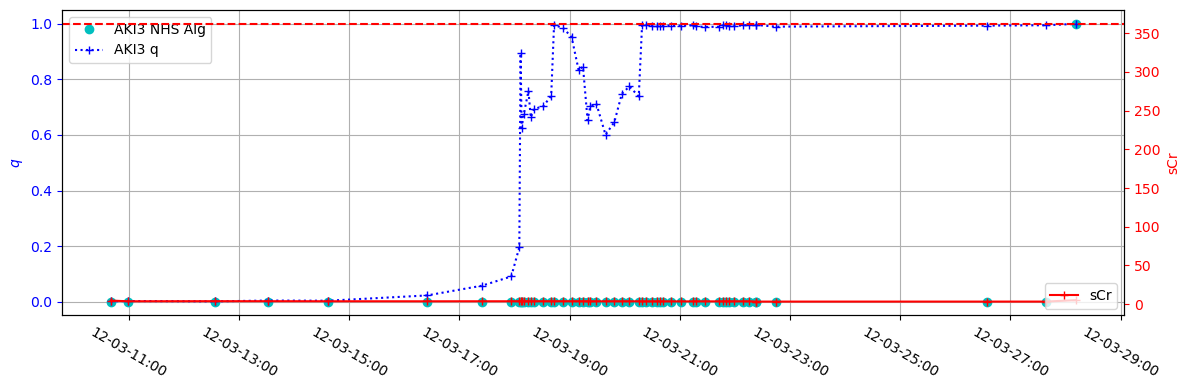

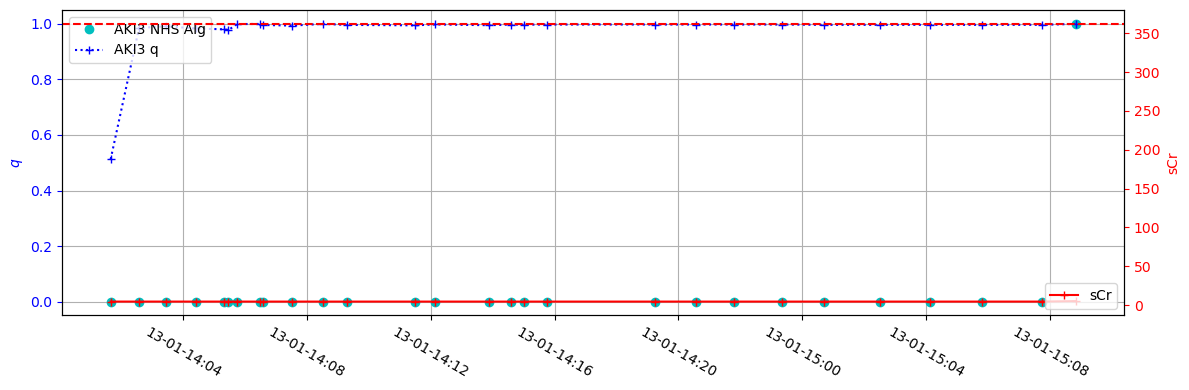

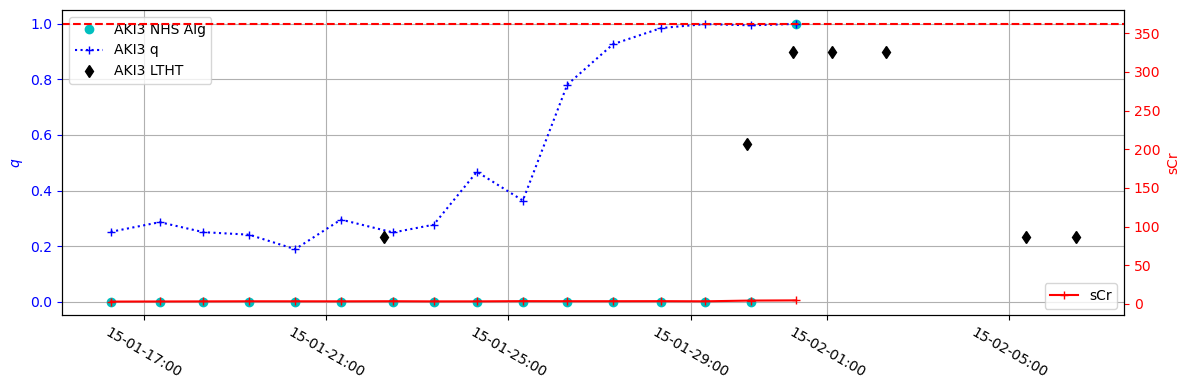

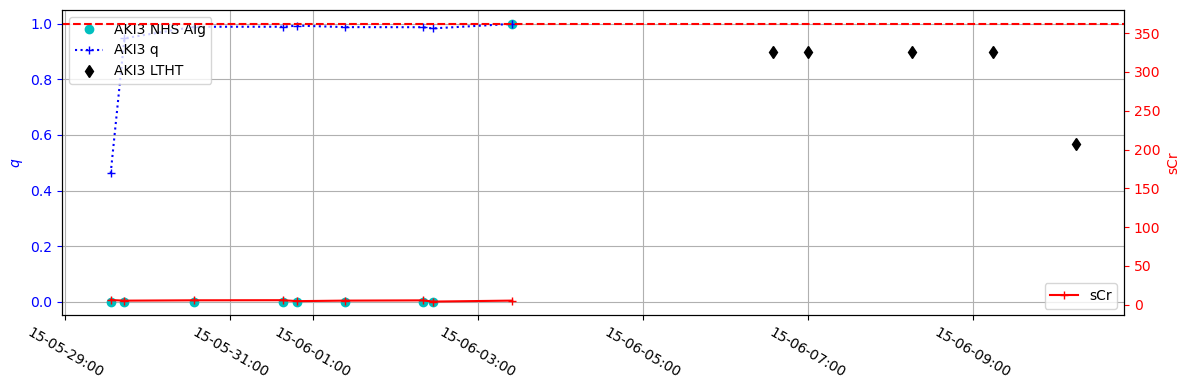

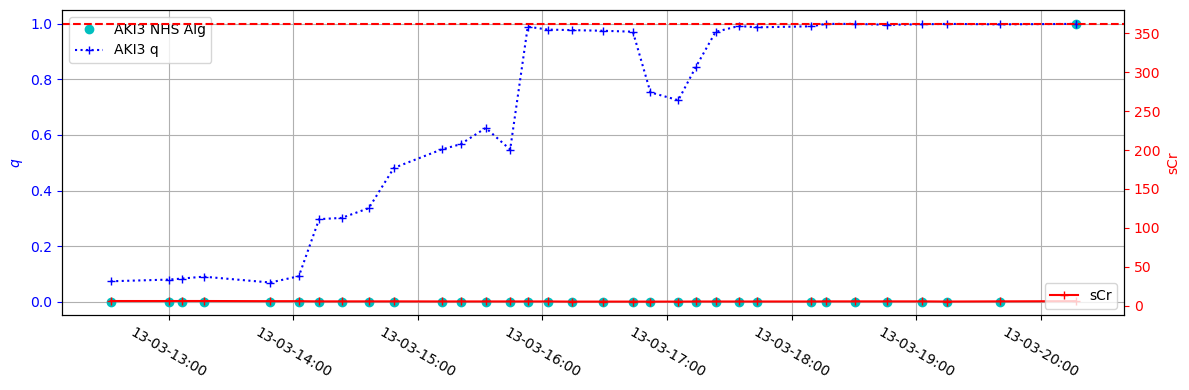

,ID,patpseudoid,Date_Test,AKI3
1830263,1204286,313944,2020-01-16 14:23:00,False
1830264,1204286,313944,2020-01-17 09:20:00,False
1830265,1204286,313944,2020-01-18 08:42:00,False
1830266,1204286,313944,2020-01-18 16:06:00,False
1830267,1204286,313944,2020-01-19 08:30:00,False
1830268,1204286,313944,2020-01-20 09:01:00,False
1830269,1204286,313944,2020-01-20 13:35:00,False
1830270,1204286,313944,2020-01-21 11:45:00,False
1830271,1204286,313944,2020-01-22 08:30:00,False
1830272,1204286,313944,2020-01-23 10:22:00,False


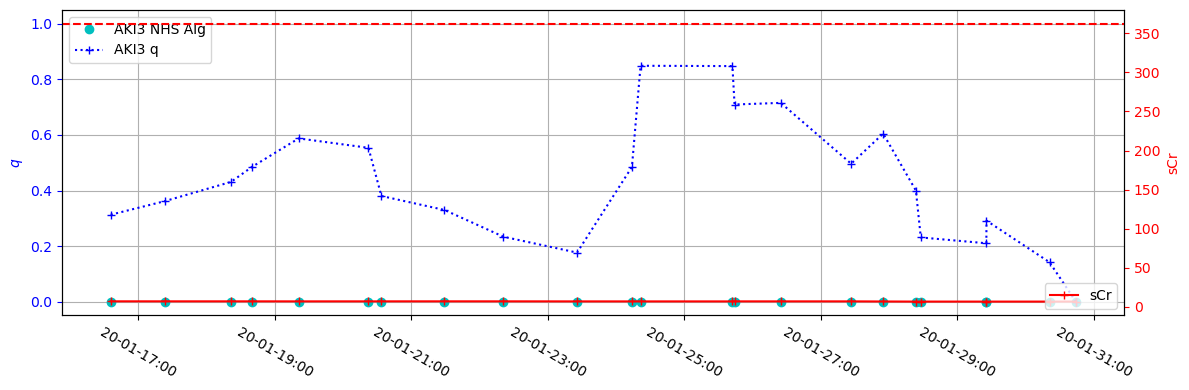

In [43]:
   


experimental.plots_patient_traj_id(1175593,df_copy,q, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=100))
experimental.plots_patient_traj_id(191816,df_copy,q, df_alert=df_alerts, id_col='ID', skip=12, dt_extend = pd.Timedelta(weeks=100))
experimental.plots_patient_traj_id(889416,df_copy,q, df_alert=df_alerts, id_col='ID', skip=40)
experimental.plots_patient_traj_id(480364,df_copy,q, df_alert=df_alerts, id_col='ID')
experimental.plots_patient_traj_id(1275237,df_copy,q, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=100))
experimental.plots_patient_traj_id(1204286,df_copy,q, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=4), print_df=True)

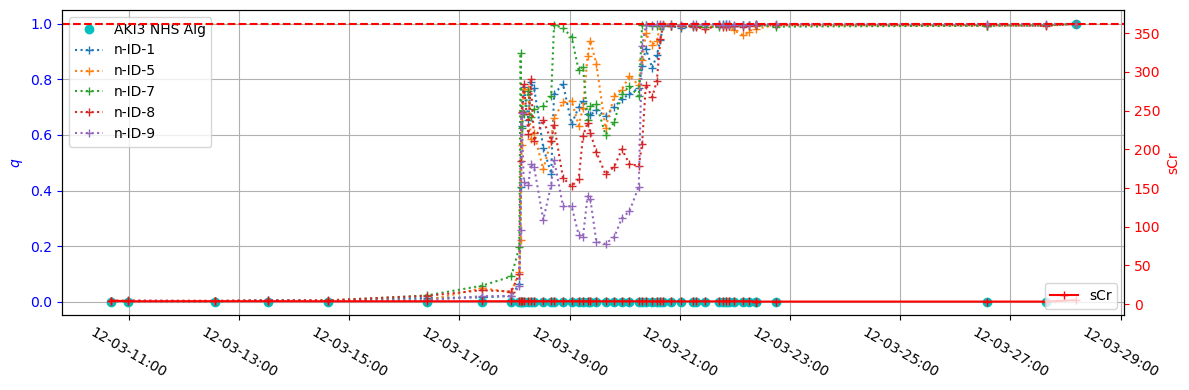

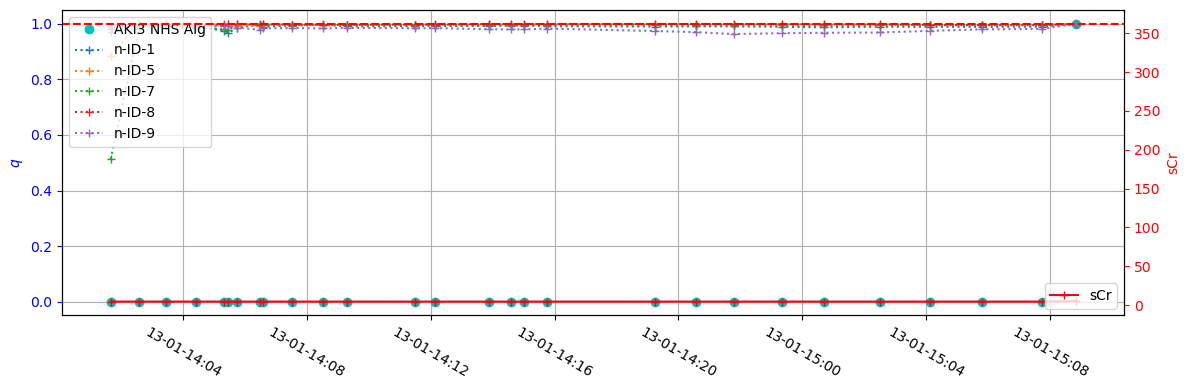

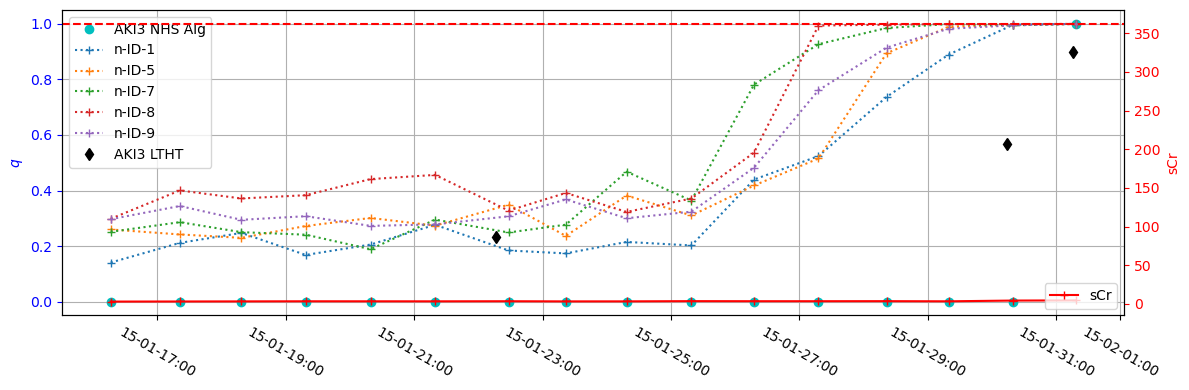

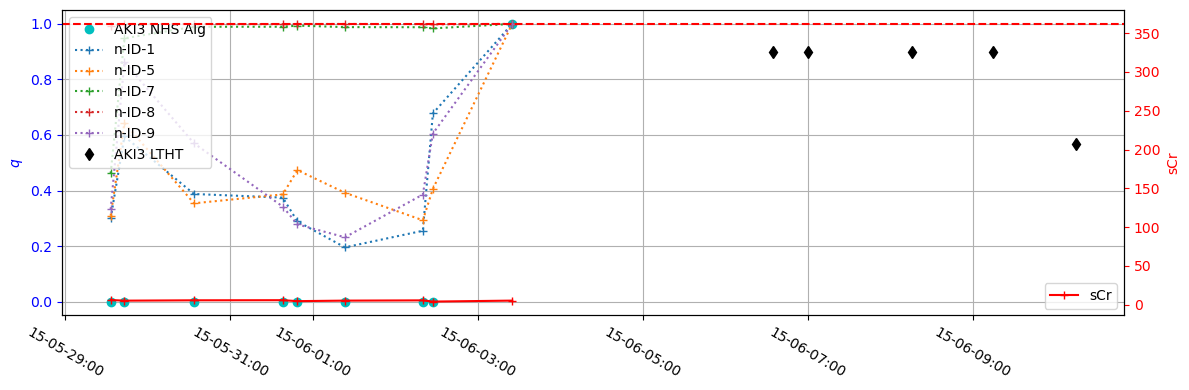

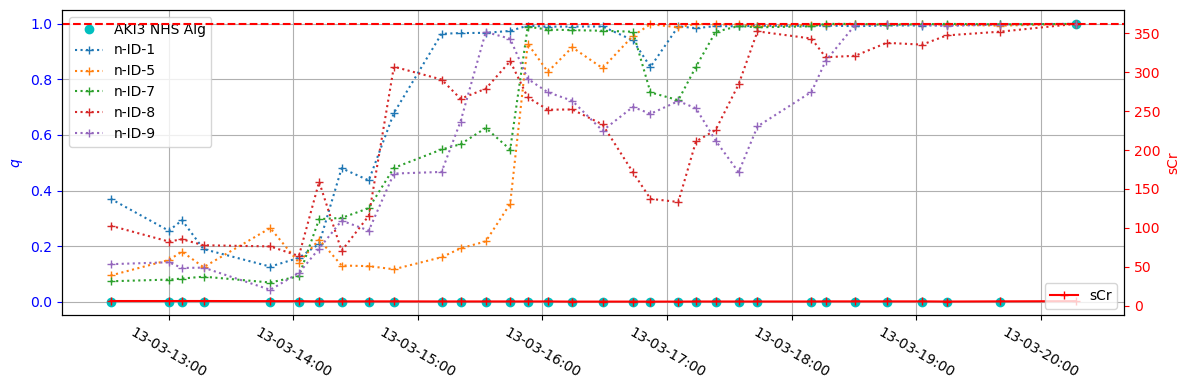

,ID,patpseudoid,Date_Test,AKI3
1830263,1204286,313944,2020-01-16 14:23:00,False
1830264,1204286,313944,2020-01-17 09:20:00,False
1830265,1204286,313944,2020-01-18 08:42:00,False
1830266,1204286,313944,2020-01-18 16:06:00,False
1830267,1204286,313944,2020-01-19 08:30:00,False
1830268,1204286,313944,2020-01-20 09:01:00,False
1830269,1204286,313944,2020-01-20 13:35:00,False
1830270,1204286,313944,2020-01-21 11:45:00,False
1830271,1204286,313944,2020-01-22 08:30:00,False
1830272,1204286,313944,2020-01-23 10:22:00,False


,patpseudoid,ID,AKI,Date_Test,patagebandataki
156208,313944,1140991.0,1,2020-02-23 01:37:00,30 to 34
138559,313944,1140991.0,1,2020-02-23 10:29:00,30 to 34


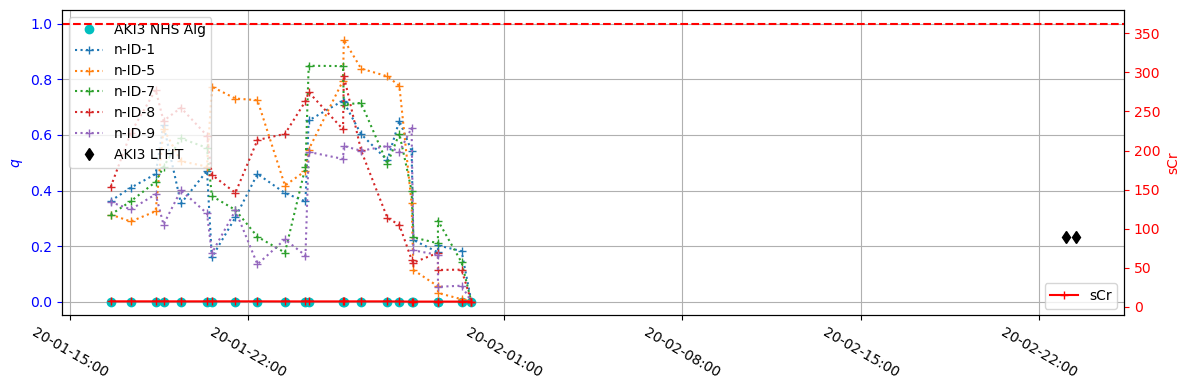

In [44]:
ltrajs=['q_trajs/committor-admissin-ID-%i.npy' %i for i in (1,5,7,8,9)]

experimental.plots_patient_bootstrap_id(1175593,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=100))
experimental.plots_patient_bootstrap_id(191816,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', skip=12, dt_extend = pd.Timedelta(weeks=100))
experimental.plots_patient_bootstrap_id(889416,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', skip=40)
experimental.plots_patient_bootstrap_id(480364,df_copy,ltrajs, df_alert=df_alerts, id_col='ID')
experimental.plots_patient_bootstrap_id(1275237,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=100))
experimental.plots_patient_bootstrap_id(1204286,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=4), print_df=True)

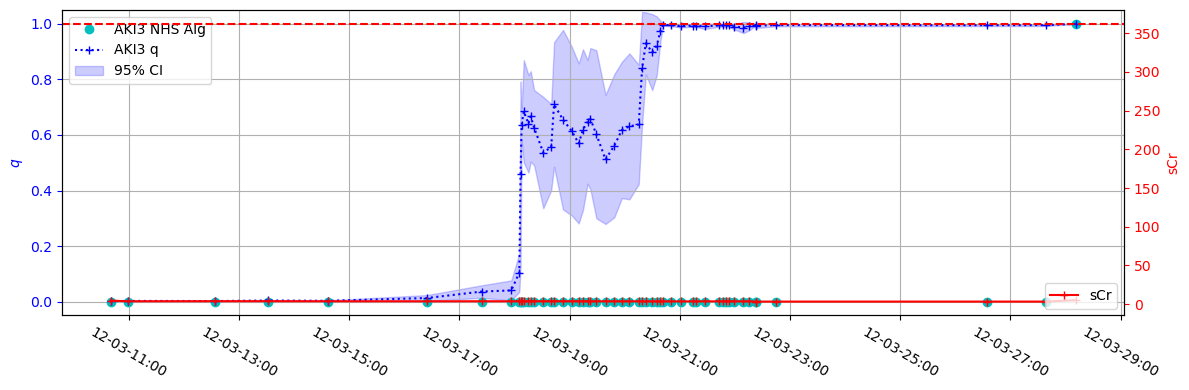

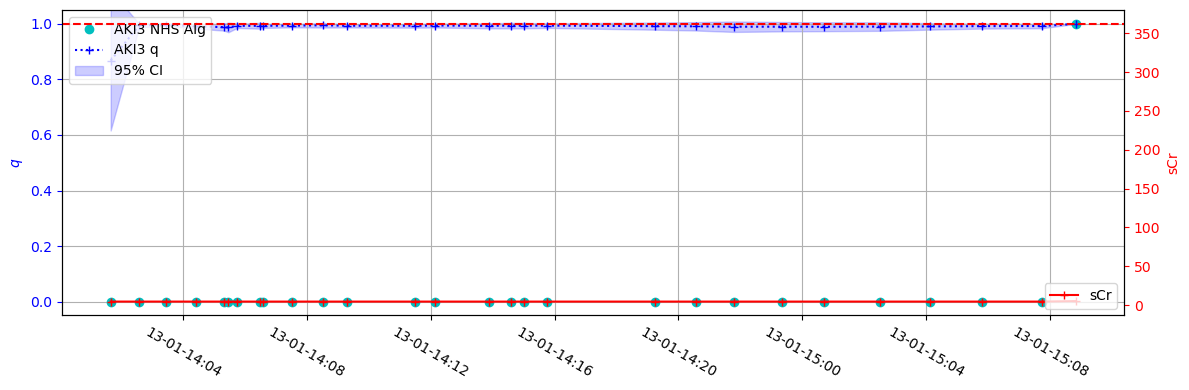

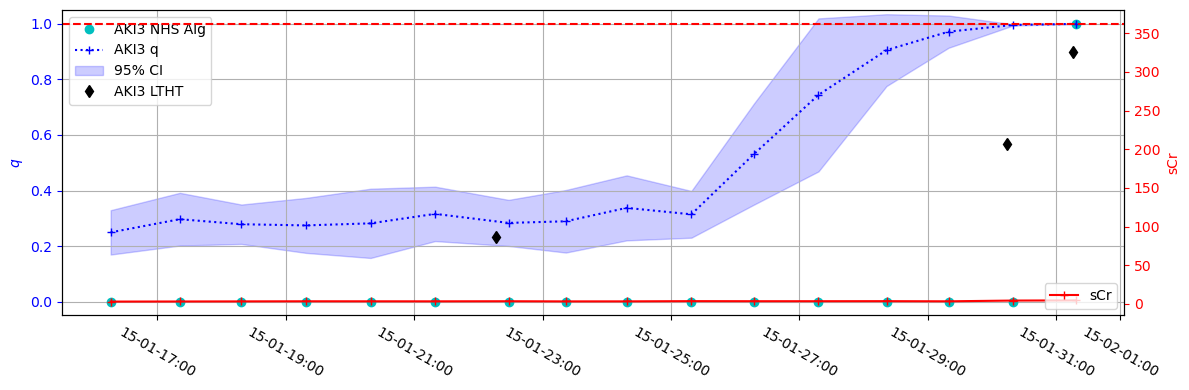

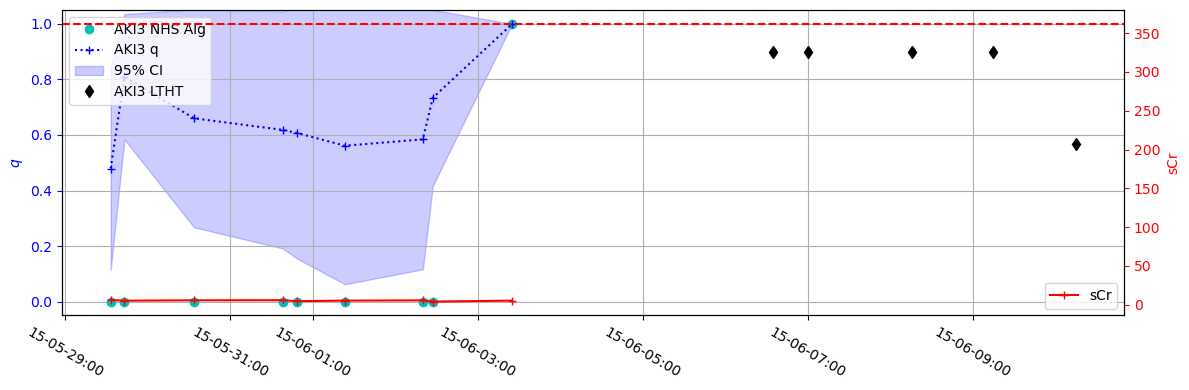

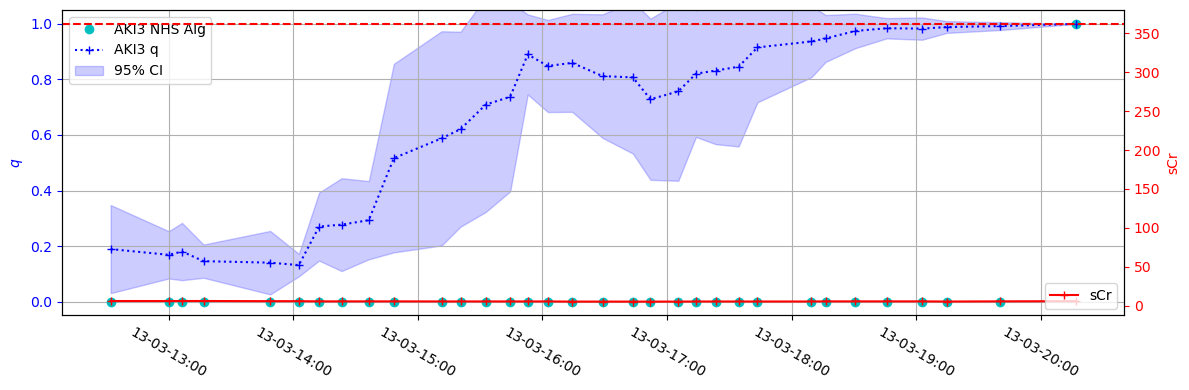

,ID,patpseudoid,Date_Test,AKI3
1830263,1204286,313944,2020-01-16 14:23:00,False
1830264,1204286,313944,2020-01-17 09:20:00,False
1830265,1204286,313944,2020-01-18 08:42:00,False
1830266,1204286,313944,2020-01-18 16:06:00,False
1830267,1204286,313944,2020-01-19 08:30:00,False
1830268,1204286,313944,2020-01-20 09:01:00,False
1830269,1204286,313944,2020-01-20 13:35:00,False
1830270,1204286,313944,2020-01-21 11:45:00,False
1830271,1204286,313944,2020-01-22 08:30:00,False
1830272,1204286,313944,2020-01-23 10:22:00,False


,patpseudoid,ID,AKI,Date_Test,patagebandataki
156208,313944,1140991.0,1,2020-02-23 01:37:00,30 to 34
138559,313944,1140991.0,1,2020-02-23 10:29:00,30 to 34


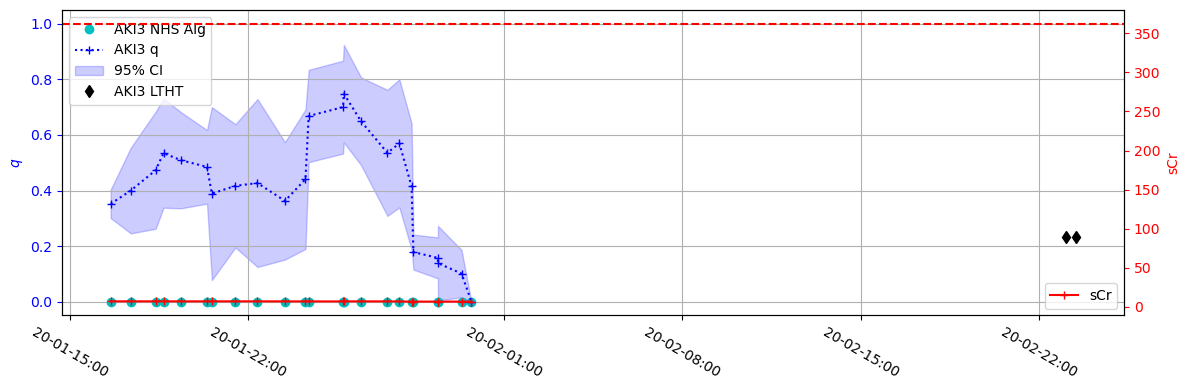

In [45]:
importlib.reload(experimental)

experimental.plots_patient_bootstrap_id(1175593,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=100), view=3)
experimental.plots_patient_bootstrap_id(191816,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', skip=12, dt_extend = pd.Timedelta(weeks=100), view=3)
experimental.plots_patient_bootstrap_id(889416,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', skip=40, view=3)
experimental.plots_patient_bootstrap_id(480364,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', view=3)
experimental.plots_patient_bootstrap_id(1275237,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=100), view=3)
experimental.plots_patient_bootstrap_id(1204286,df_copy,ltrajs, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=4), print_df=True, view=3)

In [ ]:
experimental.plots_patient_traj_id(10945,df_copy,q, df_alert=df_alerts, id_col='ID', dt_extend = pd.Timedelta(weeks=1))